<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/Zoo.csv")

In [6]:
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [7]:
df.drop(columns=['animal name'],inplace=True)

In [8]:
df

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


#No Null Values

In [9]:
df.isnull().sum()

,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0
breathes,0


In [10]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   hair      101 non-null    int64
 1   feathers  101 non-null    int64
 2   eggs      101 non-null    int64
 3   milk      101 non-null    int64
 4   airborne  101 non-null    int64
 5   aquatic   101 non-null    int64
 6   predator  101 non-null    int64
 7   toothed   101 non-null    int64
 8   backbone  101 non-null    int64
 9   breathes  101 non-null    int64
 10  venomous  101 non-null    int64
 11  fins      101 non-null    int64
 12  legs      101 non-null    int64
 13  tail      101 non-null    int64
 14  domestic  101 non-null    int64
 15  catsize   101 non-null    int64
 16  type      101 non-null    int64
dtypes: int64(17)
memory usage: 13.5 KB


<Axes: ylabel='Count'>

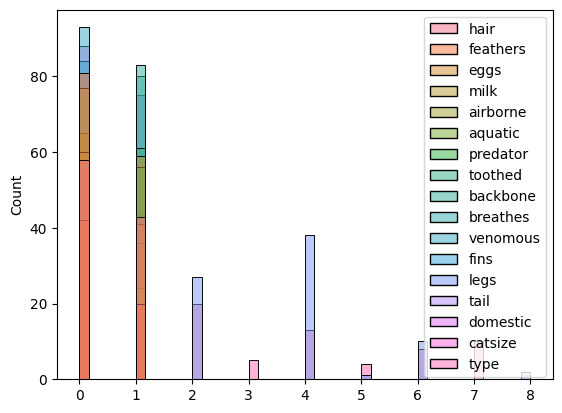

In [12]:
sns.histplot(df)

<Axes: >

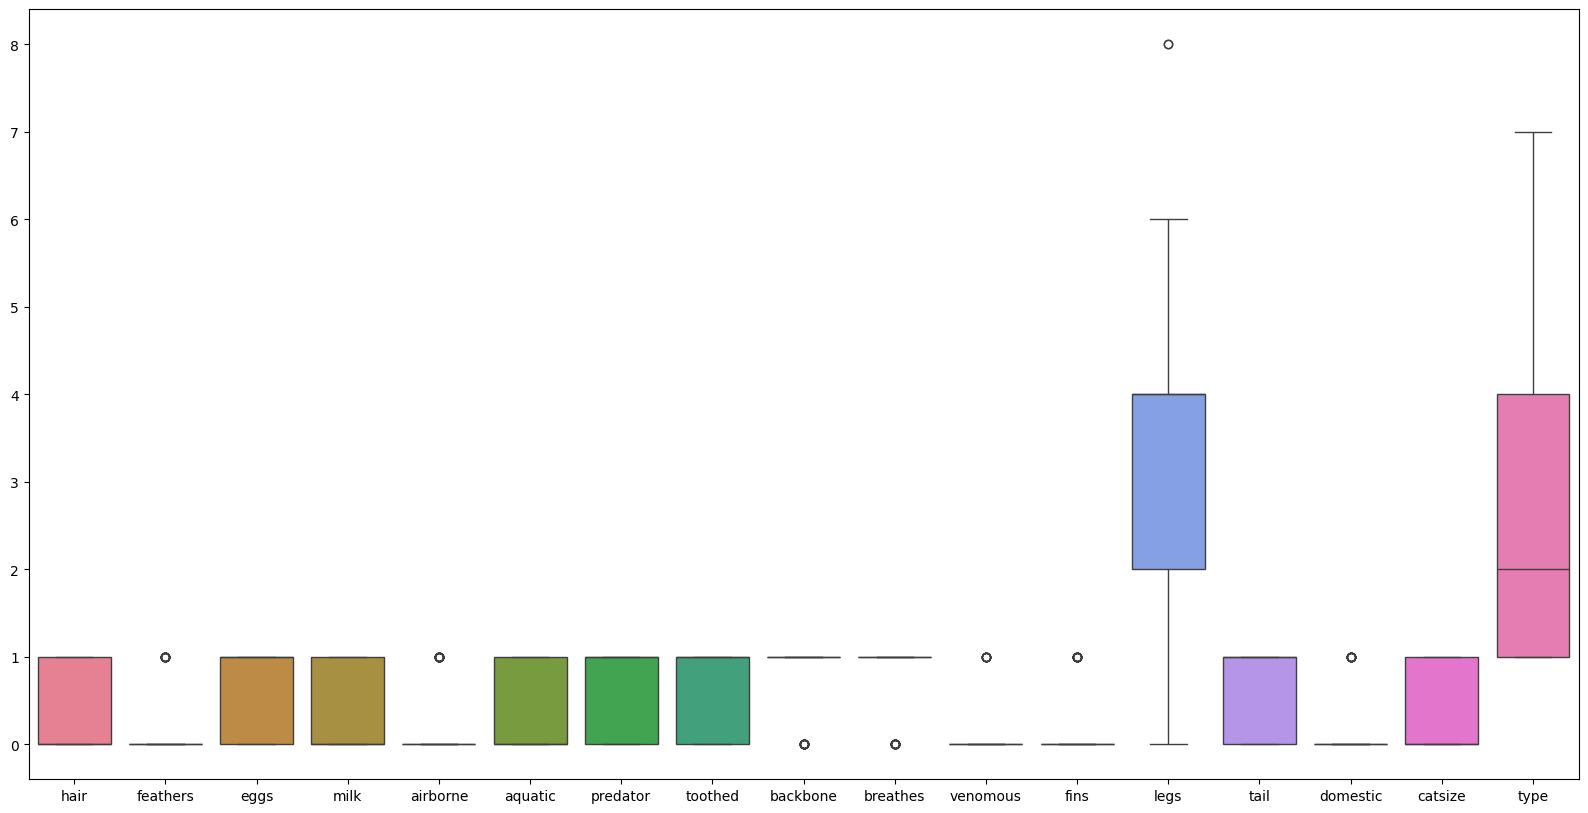

In [13]:

plt.figure(figsize=(20,10))
sns.boxplot(df)

#from abbove boxPLot we can observ that feathers, airborne, backbone, breathes, venemous, fins and domestics can be ignored or dropped as they ae less


In [14]:
df = df.drop(columns= ['feathers','airborne','backbone','breathes','fins','domestic'])

In [15]:
df.head()

,hair,eggs,milk,aquatic,predator,toothed,venomous,legs,tail,catsize,type
0,1,0,1,0,1,1,0,4,0,1,1
1,1,0,1,0,0,1,0,4,1,1,1
2,0,1,0,1,1,1,0,0,1,0,4
3,1,0,1,0,1,1,0,4,0,1,1
4,1,0,1,0,1,1,0,4,1,1,1


<Axes: >

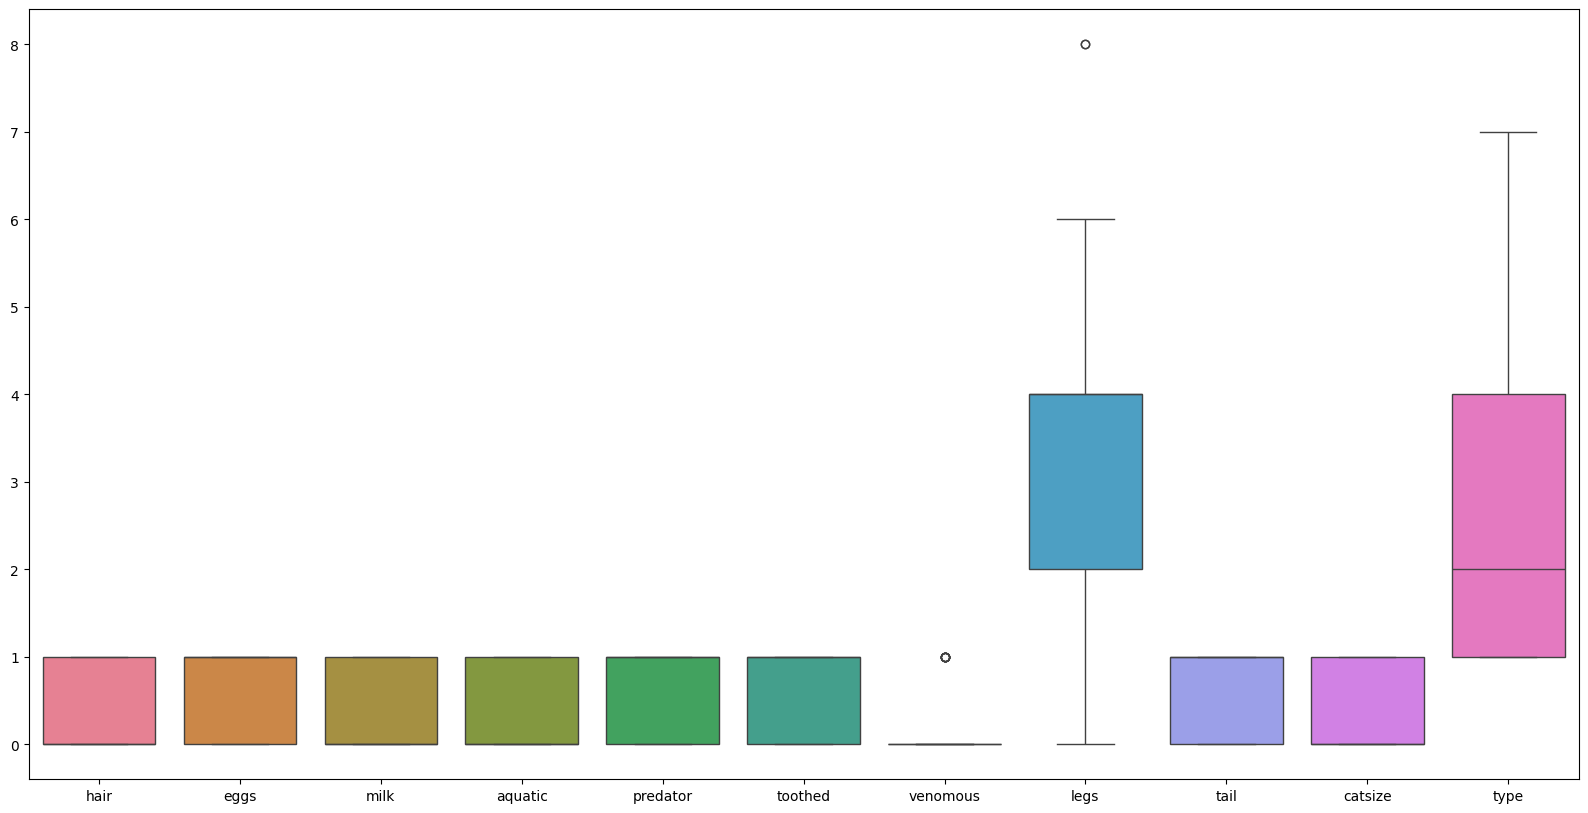

In [16]:
plt.figure(figsize=(20,10))
sns.boxplot(df)

In [17]:
df = df.drop(columns=['venomous'])

In [18]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [19]:
x

,hair,eggs,milk,aquatic,predator,toothed,legs,tail,catsize
0,1,0,1,0,1,1,4,0,1
1,1,0,1,0,0,1,4,1,1
2,0,1,0,1,1,1,0,1,0
3,1,0,1,0,1,1,4,0,1
4,1,0,1,0,1,1,4,1,1
...,...,...,...,...,...,...,...,...,...
96,1,0,1,0,0,1,2,1,1
97,1,1,0,0,0,0,6,0,0
98,1,0,1,0,1,1,4,1,1
99,0,1,0,0,0,0,0,0,0


In [34]:
y

,type
0,1
1,1
2,4
3,1
4,1
...,...
96,1
97,6
98,1
99,7


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy="auto", random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [40]:
print(y_train.value_counts())

type
1    29
2    18
4    11
7     9
6     5
5     4
3     4
Name: count, dtype: int64


#there are some UnderSampling data


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
kfold = KFold(n_splits=10)
from sklearn.model_selection import cross_val_score
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train,y_train)
results = cross_val_score(knn, x, y, cv=kfold)

In [23]:
y_pred = knn.predict(x_test)

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, f1_score
confusion_matrix(y_test,y_pred)
f1_score(y_test, y_pred, average='micro')
accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.50      1.00      0.67         2
           6       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         1

    accuracy                           0.90        21
   macro avg       0.58      0.67      0.61        21
weighted avg       0.86      0.90      0.87        21



#by changing the nearest neighbours to 4 we have achieved 90% accuracy


In [28]:
from sklearn.model_selection import GridSearchCV
n_neighbors = np.array(range(1,40))
param_grid = dict(n_neighbors=n_neighbors)

In [29]:
model = KNeighborsClassifier()
grid = GridSearchCV(estimator=model, param_grid=param_grid)
grid.fit(x, y)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39])})

In [30]:
print(grid.best_score_)
print(grid.best_params_)

0.95
{'n_neighbors': np.int64(1)}


#by using GridSearch we can identify correct number of Neighbours required for high accuracy


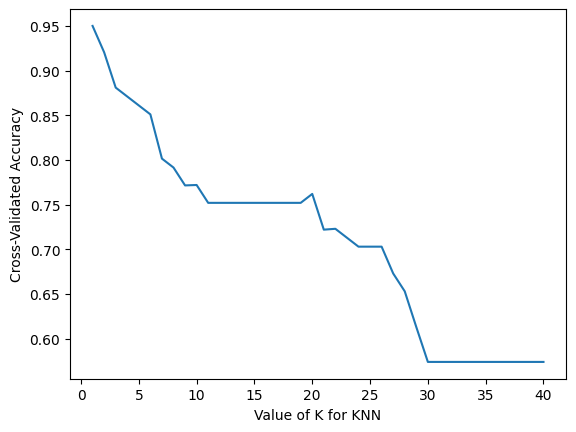

In [31]:
k_range = range(1, 41)
k_scores = []
# use iteration to caclulator different k in models, then return the average accuracy based on the cross validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x, y, cv=5)
    k_scores.append(scores.mean())
# plot to see clearly
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

#Key Hyperparameters in KNN:

n_neighbors (k): Number of nearest neighbors to consider.

metric: Distance function (e.g., Euclidean, Manhattan).

weights: "uniform" (equal weight) or "distance" (closer neighbors have more influence).

#Distance Metrics in KNN:

Euclidean Distance (default, best for continuous data).

Manhattan Distance (useful for grid-like data).

Minkowski Distance (generalized form of Euclidean and Manhattan).

Hamming Distance (for categorical data).